In [1]:
import numpy as np
from pathlib import Path
from scipy.ndimage import uniform_filter1d

from brainvision.constants import *
from brainvision.data import load_patient, list_patient_zips

## Pre-processing

In [2]:
def calibrate(raw: np.ndarray,
              dark: np.ndarray,
              white: np.ndarray,
              eps: float = 1e-6) -> np.ndarray:
    """
    Convert raw DN to reflectance: R = (raw - dark) / (white - dark)
    Follows Fabelo et al. (2023) Eq. 1.
    Input:  (H, W, B)
    Output: (H, W, B) float32 in [0, 1]
    """
    dark_mean  = dark.mean(axis=0,  keepdims=True)    # (1, W, B)
    white_mean = white.mean(axis=0, keepdims=True)    # (1, W, B)
    R = (raw - dark_mean) / (white_mean - dark_mean + eps)
    return np.clip(R, 0, 1).astype(np.float32)

In [3]:
def smooth_spectra(cube: np.ndarray, window: int = SMOOTH_WINDOW) -> np.ndarray:
    """
    Apply moving average filter along spectral axis to reduce
    high-frequency noise. Window=5 as per Fabelo et al. (2023).
    Input / Output: (H, W, B)
    """
    return uniform_filter1d(cube, size=window, axis=2).astype(np.float32)

In [4]:
def remove_noisy_bands(cube: np.ndarray) -> np.ndarray:
    """
    Remove first 56 and last 126 spectral channels due to low CCD
    sensor performance at spectral extremes (Fabelo et al., 2023).
    Input:  (H, W, 826)
    Output: (H, W, 644)
    """
    return cube[:, :, BAND_START_IDX:BAND_END_IDX].astype(np.float32)

In [5]:
def decimate_spectral_channels(cube: np.ndarray,
                               n_output: int = N_DECIMATED_BANDS) -> np.ndarray:
    """
    Uniformly subsample spectral channels to n_output bands.
    Follows Fabelo et al. (2023) optimal sampling interval of 3.61nm → 128 channels.
    Input:  (H, W, 644)
    Output: (H, W, 128)
    """
    B       = cube.shape[2]
    indices = np.linspace(0, B - 1, n_output, dtype=int)
    return cube[:, :, indices].astype(np.float32)

In [6]:
def minmax_normalise(cube: np.ndarray) -> np.ndarray:
    """
    Per-pixel Min-Max normalisation across the spectral axis to [0, 1].
    Follows Fabelo et al. (2023).
    Input / Output: (H, W, B)
    """
    H, W, B   = cube.shape
    pixels    = cube.reshape(-1, B)                        # (H*W, B)
    mn        = pixels.min(axis=1, keepdims=True)          # (H*W, 1)
    mx        = pixels.max(axis=1, keepdims=True)          # (H*W, 1)
    normed    = (pixels - mn) / (mx - mn + 1e-6)
    return normed.reshape(H, W, B).astype(np.float32)

In [7]:
def preprocess(patient: dict) -> dict:
    """
    Full preprocessing pipeline following Fabelo et al. (2023):
      1. Calibration     (H, W, 826) → reflectance [0, 1]
      2. Smoothing       moving average window=5
      3. Band removal    (H, W, 826) → (H, W, 644)
      4. Decimation      (H, W, 644) → (H, W, 128)
      5. Normalisation   per-pixel Min-Max [0, 1]

    Adds 'processed' key — (H, W, 128) float32.
    """
    print(f"  Processing {patient['id']}...", end=" ")

    cube = calibrate(patient['raw'], patient['dark'], patient['white'])
    cube = smooth_spectra(cube)
    cube = remove_noisy_bands(cube)
    cube = decimate_spectral_channels(cube)
    cube = minmax_normalise(cube)

    print(f"✅  {cube.shape}  [{cube.min():.3f}, {cube.max():.3f}]")

    patient['processed'] = cube
    return patient

In [8]:
def save_processed_patient(patient: dict,
                            out_dir: str = DATA_PROCESSED_DIR):
    """
    Save preprocessed cube and labels to a compressed .npz file.
    Filename: {patient_id}.npz
    """
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    out_path = Path(out_dir) / f"{patient['id']}.npz"

    np.savez_compressed(
        out_path,
        processed = patient['processed'],   # (H, W, 128) float32
        labels    = patient['labels'],       # (H, W)      int32
    )
    return out_path

In [9]:
def load_processed_patient(npz_path: Path) -> dict:
    """Load a single preprocessed patient from a .npz file."""
    data = np.load(npz_path)
    return {
        'id'        : npz_path.stem,
        'processed' : data['processed'],    # (H, W, 128) float32
        'labels'    : data['labels'],        # (H, W)      int32
    }

In [10]:
def load_processed_patients(data_dir: str = PROCESSED_DIRS[1]) -> list[dict]:
    """
    Load all preprocessed patients from disk.
    Used at the top of 03_training.ipynb and 04_evaluation.ipynb.
    """
    paths    = sorted(Path(data_dir).glob("*.npz"))
    patients = [load_processed_patient(p) for p in paths]
    print(f"Loaded {len(patients)} preprocessed patients from {data_dir}")
    return patients

In [11]:
def preprocess_all(data_dir:  str = CAMPAIGN_DIRS[1],
                   out_dir:   str = PROCESSED_DIRS[1],
                   overwrite: bool = False):
    """
    Load, preprocess, and save all patient ZIPs to disk.

    Args:
        data_dir  : folder containing raw .zip files
        out_dir   : folder to save .npz files
        overwrite : if False, skip patients already saved to disk
    """
    all_zips = list_patient_zips(data_dir)
    print(f"Found {len(all_zips)} patient ZIPs in {data_dir}")
    print(f"Saving preprocessed files to {out_dir}\n")

    saved, skipped = 0, 0

    for zip_path in all_zips:
        out_path = Path(out_dir) / f"{zip_path.stem}.npz"

        if out_path.exists() and not overwrite:
            print(f"  Skipping {zip_path.stem} — already exists")
            skipped += 1
            continue

        patient  = load_patient(str(zip_path), cleanup=True)
        patient  = preprocess(patient)
        saved_to = save_processed_patient(patient, out_dir)

        # Free memory before next patient
        del patient
        saved += 1

    print(f"\n{'─'*50}")
    print(f"  Saved   : {saved}")
    print(f"  Skipped : {skipped}")
    print(f"  Total   : {saved + skipped} / {len(all_zips)}")
    print(f"{'─'*50}")


In [12]:
def verify_processed(data_dir: str = PROCESSED_DIRS[1]):
    """
    Quick verification — print shape, dtype, and value range
    for every saved .npz file.
    """
    paths = sorted(Path(data_dir).glob("*.npz"))
    print(f"\n{'ID':<12} {'Processed Shape':<20} {'Labels Shape':<15} "
          f"{'Min':>6} {'Max':>6} {'dtype'}")
    print("─" * 70)

    for p in paths:
        d = np.load(p)
        print(f"  {p.stem:<12} {str(d['processed'].shape):<20} "
              f"{str(d['labels'].shape):<15} "
              f"{d['processed'].min():>6.3f} {d['processed'].max():>6.3f} "
              f"{d['processed'].dtype}")

    print(f"\n✅ {len(paths)} files verified")

In [13]:
for campaign in [1, 2]:
    print(f"\n{'═'*50}")
    print(f"  Campaign {campaign}")
    print(f"{'═'*50}")
    preprocess_all(
        data_dir  = CAMPAIGN_DIRS[campaign],
        out_dir   = PROCESSED_DIRS[campaign],
        overwrite = False
    )
    verify_processed(PROCESSED_DIRS[campaign])

# ── Load all processed patients for post-preprocessing EDA ───────────────────
all_patients = []
for campaign in [1, 2, 3]:
    all_patients.extend(load_processed_patients(PROCESSED_DIRS[campaign]))

print(f"\nTotal patients loaded: {len(all_patients)}")


══════════════════════════════════════════════════
  Campaign 1
══════════════════════════════════════════════════
Found 27 patient ZIPs in ../datasets/first_campaign
Saving preprocessed files to ../processed/first_campaign

  Skipping 004-02 — already exists
  Skipping 005-01 — already exists
  Skipping 007-01 — already exists
  Skipping 008-01 — already exists
  Skipping 008-02 — already exists
  Skipping 010-03 — already exists
  Skipping 012-01 — already exists
  Skipping 012-02 — already exists
  Skipping 013-01 — already exists
  Skipping 014-01 — already exists
  Skipping 015-01 — already exists
  Skipping 016-01 — already exists
  Skipping 016-02 — already exists
  Skipping 016-03 — already exists
  Skipping 016-04 — already exists
  Skipping 016-05 — already exists
  Skipping 017-01 — already exists
  Skipping 018-01 — already exists
  Skipping 018-02 — already exists
  Skipping 019-01 — already exists
  Skipping 020-01 — already exists
  Skipping 021-01 — already exists
  Sk

In [14]:
import matplotlib.pyplot as plt

def plot_processed_band_profiles(patients: list[dict], n_patients: int = None):
    """
    Plot mean processed spectrum per patient after full preprocessing pipeline.
    Companion to plot_raw_band_profiles — confirms:
      - All patients normalised to [0, 1]
      - Uniform 128-band decimated range
      - No outlier patients remaining after calibration
    """
    n   = len(patients) if n_patients is None else n_patients
    fig, ax = plt.subplots(figsize=(12, 5))

    for p in patients[:n]:
        cube          = p['processed']                           # (H, W, 128)
        mean_per_band = cube.reshape(-1, cube.shape[2]).mean(axis=0)   # (128,)
        ax.plot(mean_per_band, alpha=0.7, label=p['id'])

    ax.set_xlabel("Decimated band index (0-127)")
    ax.set_ylabel("Mean normalised reflectance")
    ax.set_title("Processed spectral profiles — after full preprocessing pipeline\n"
                 "(calibration → smoothing → band removal → decimation → normalisation)")
    ax.set_xlim(0, 127)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, ncol=3)
    plt.tight_layout()
    plt.show()


def plot_processed_class_spectra(patients: list[dict], n_patients: int = None):
    """
    Mean processed spectrum per tissue class after preprocessing.
    Companion to plot_raw_class_spectra — confirms class separability
    is preserved or improved after the preprocessing pipeline.
    """
    n        = len(patients) if n_patients is None else n_patients
    combined = {c: [] for c in [1, 2, 3, 4]}

    for p in patients[:n]:
        cube        = p['processed']                           # (H, W, 128)
        flat_px     = cube.reshape(-1, cube.shape[2])          # (H*W, 128)
        flat_labels = p['labels'].reshape(-1)                  # (H*W,)

        for c in [1, 2, 3, 4]:
            mask = flat_labels == c
            if mask.sum() > 0:
                combined[c].append(flat_px[mask].mean(axis=0))

    fig, ax = plt.subplots(figsize=(11, 5))

    for c in [1, 2, 3, 4]:
        if combined[c]:
            stack = np.stack(combined[c])
            mean  = stack.mean(axis=0)
            std   = stack.std(axis=0)
            ax.plot(mean, color=CLASS_COLORS[c], label=CLASS_NAMES[c])
            ax.fill_between(range(len(mean)),
                            mean - std, mean + std,
                            alpha=0.15, color=CLASS_COLORS[c])

    ax.set_xlabel("Decimated band index (0-127)")
    ax.set_ylabel("Mean normalised reflectance")
    ax.set_title("Processed class spectral signatures — after preprocessing (mean ± std across patients)")
    ax.set_xlim(0, 127)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

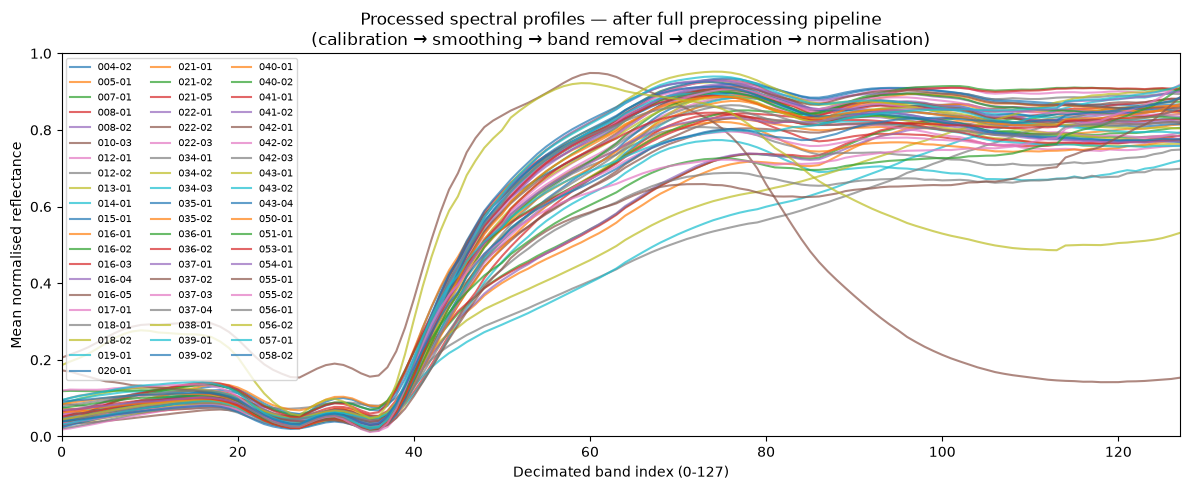

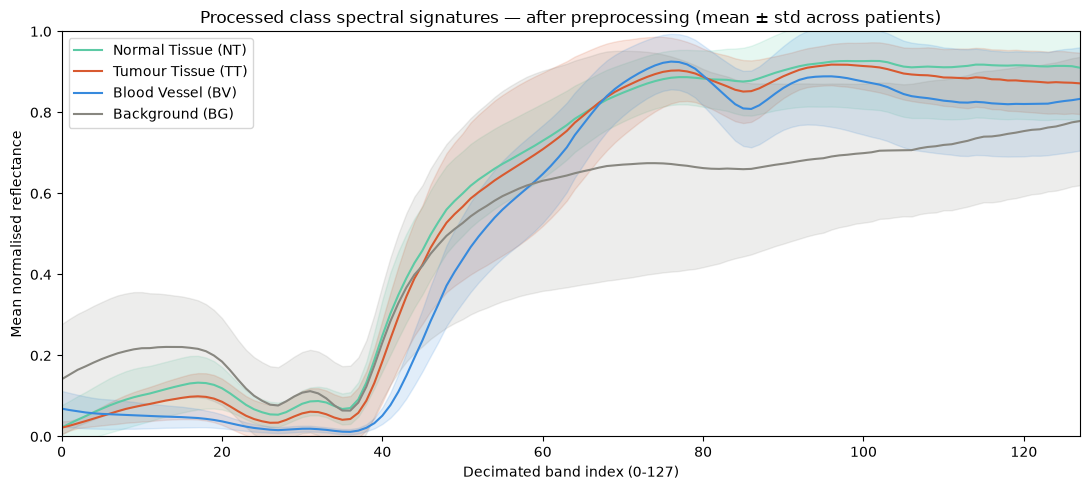

In [15]:
plot_processed_band_profiles(all_patients)
plot_processed_class_spectra(all_patients)

In [16]:
def plot_preprocessing_pipeline(zip_path: str, patient_id: str = None):
    """
    Visualise the effect of each preprocessing step on a single patient.
    Shows spectral profiles and spatial mean intensity maps at each stage.

    Steps shown:
      0. Raw DN
      1. After calibration
      2. After smoothing
      3. After band removal
      4. After decimation
      5. After normalisation (final)
    """
    # ── Load raw patient ──────────────────────────────────────────────────────
    patient    = load_patient(zip_path)
    patient_id = patient_id or patient['id']

    raw   = patient['raw']
    dark  = patient['dark']
    white = patient['white']

    # ── Apply steps sequentially ──────────────────────────────────────────────
    step0 = raw                          # raw DN
    step1 = calibrate(raw, dark, white)  # calibration
    step2 = smooth_spectra(step1)        # smoothing
    step3 = remove_noisy_bands(step2)    # band removal
    step4 = decimate_spectral_channels(step3)  # decimation
    step5 = minmax_normalise(step4)      # normalisation

    labels     = patient['labels'].reshape(-1)
    steps      = [step0, step1, step2, step3, step4, step5]
    step_names = [
        "0. Raw DN",
        "1. Calibration\n(DN → Reflectance)",
        "2. Smoothing\n(Moving avg, w=5)",
        "3. Band Removal\n(826 → 644 bands)",
        "4. Decimation\n(644 → 128 bands)",
        "5. Normalisation\n(per-pixel min-max)",
    ]
    colors = ['#888780', '#378ADD', '#5DCAA5', '#EF9F27', '#7F77DD', '#D85A30']

    # ════════════════════════════════════════════════════════════════
    # Figure 1 — Mean spectral profile at each step
    # ════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Preprocessing pipeline — Patient {patient_id}\n"
                 f"Mean spectral profile at each step", fontsize=13)
    axes = axes.flatten()

    for i, (step, name, color) in enumerate(zip(steps, step_names, colors)):
        ax         = axes[i]
        flat       = step.reshape(-1, step.shape[2])
        mean_band  = flat.mean(axis=0)
        std_band   = flat.std(axis=0)
        x          = np.arange(len(mean_band))

        ax.plot(mean_band, color=color, linewidth=1.5)
        ax.fill_between(x, mean_band - std_band, mean_band + std_band,
                        alpha=0.2, color=color)

        # Mark removed bands on raw and calibrated plots
        if i in [0, 1]:
            ax.axvspan(0,   BAND_START_IDX,  alpha=0.12, color='red',
                       label=f'Removed (0–{BAND_START_IDX})')
            ax.axvspan(BAND_END_IDX, step.shape[2], alpha=0.12, color='red',
                       label=f'Removed ({BAND_END_IDX}–{step.shape[2]})')
            ax.legend(fontsize=7)

        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Band index")
        ax.set_ylabel("Mean value")
        ax.set_xlim(0, len(mean_band) - 1)

    plt.tight_layout()
    plt.show()

    # ════════════════════════════════════════════════════════════════
    # Figure 2 — Per-class mean spectra at each step
    # ════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Preprocessing pipeline — Patient {patient_id}\n"
                 f"Per-class mean spectra at each step", fontsize=13)
    axes = axes.flatten()

    for i, (step, name) in enumerate(zip(steps, step_names)):
        ax       = axes[i]
        flat_px  = step.reshape(-1, step.shape[2])

        for c in [1, 2, 3, 4]:
            mask = labels == c
            if mask.sum() > 0:
                mean = flat_px[mask].mean(axis=0)
                ax.plot(mean, color=CLASS_COLORS[c],
                        label=CLASS_NAMES_SHORT[c], linewidth=1.5)

        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Band index")
        ax.set_ylabel("Mean value")
        ax.set_xlim(0, step.shape[2] - 1)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # ════════════════════════════════════════════════════════════════
    # Figure 3 — Spatial mean intensity map at each step
    # ════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Preprocessing pipeline — Patient {patient_id}\n"
                 f"Spatial mean intensity map at each step", fontsize=13)
    axes = axes.flatten()

    for i, (step, name, color) in enumerate(zip(steps, step_names, colors)):
        ax       = axes[i]
        mean_map = step.mean(axis=2)    # (H, W) — mean across bands
        im       = ax.imshow(mean_map, cmap='gray')
        ax.set_title(name, fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)

    plt.tight_layout()
    plt.show()

    # ════════════════════════════════════════════════════════════════
    # Figure 4 — Pixel intensity histogram at each step
    # ════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    fig.suptitle(f"Preprocessing pipeline — Patient {patient_id}\n"
                 f"Pixel intensity distribution at each step", fontsize=13)
    axes = axes.flatten()

    for i, (step, name, color) in enumerate(zip(steps, step_names, colors)):
        ax      = axes[i]
        sample  = step.reshape(-1)[::10]    # subsample for speed
        ax.hist(sample, bins=80, color=color, alpha=0.8, density=True)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Intensity value")
        ax.set_ylabel("Density")
        ax.set_xlim(sample.min(), sample.max())

    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────────
    print(f"\n{'─'*65}")
    print(f"  {'Step':<35} {'Shape':>15}  {'Min':>7}  {'Max':>7}  {'Mean':>7}")
    print(f"{'─'*65}")
    for step, name in zip(steps, step_names):
        name_clean = name.replace('\n', ' ')
        print(f"  {name_clean:<35} {str(step.shape):>15}  "
              f"{step.min():>7.3f}  {step.max():>7.3f}  {step.mean():>7.3f}")
    print(f"{'─'*65}")

In [31]:
patient_path = "../datasets/first_campaign/008-02.zip"

patient = load_patient(patient_path)
labels  = patient['labels'].reshape(-1)

for c in [1, 2, 3, 4]:
    count = (labels == c).sum()
    print(f"  {CLASS_NAMES[c]:<25}: {count:,} pixels")

  Normal Tissue (NT)       : 2,187 pixels
  Tumour Tissue (TT)       : 138 pixels
  Blood Vessel (BV)        : 1,000 pixels
  Background (BG)          : 7,444 pixels


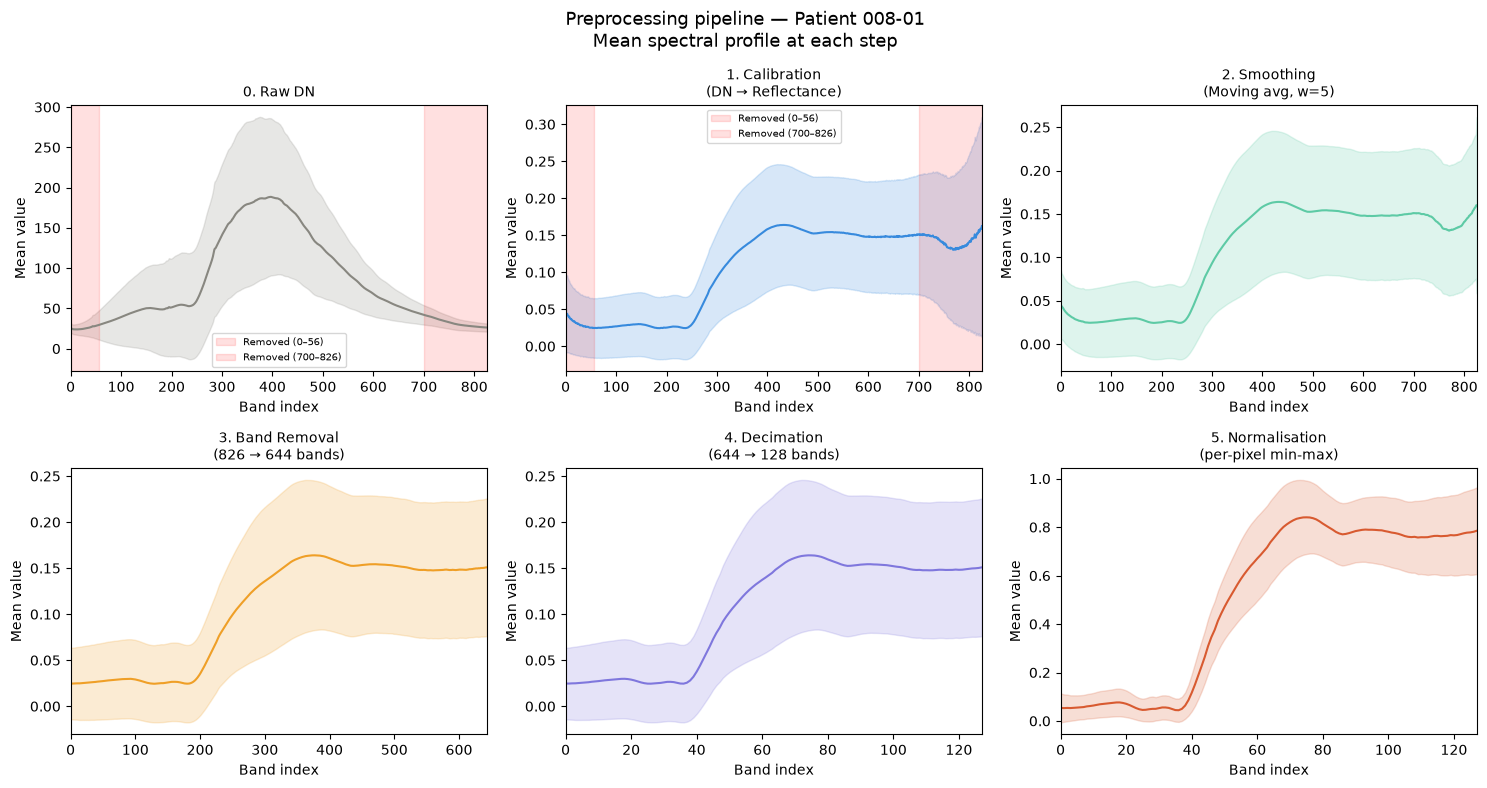

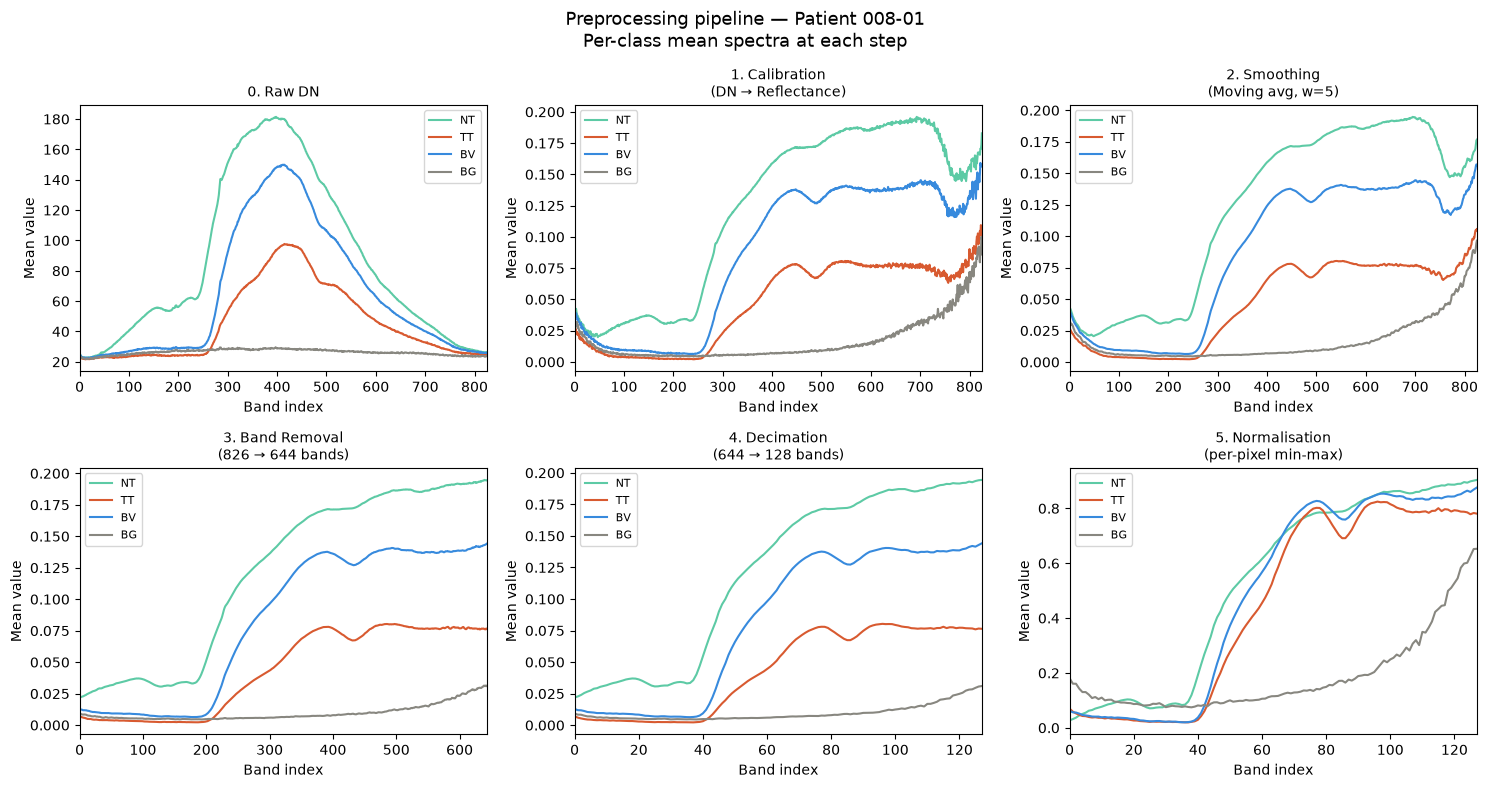

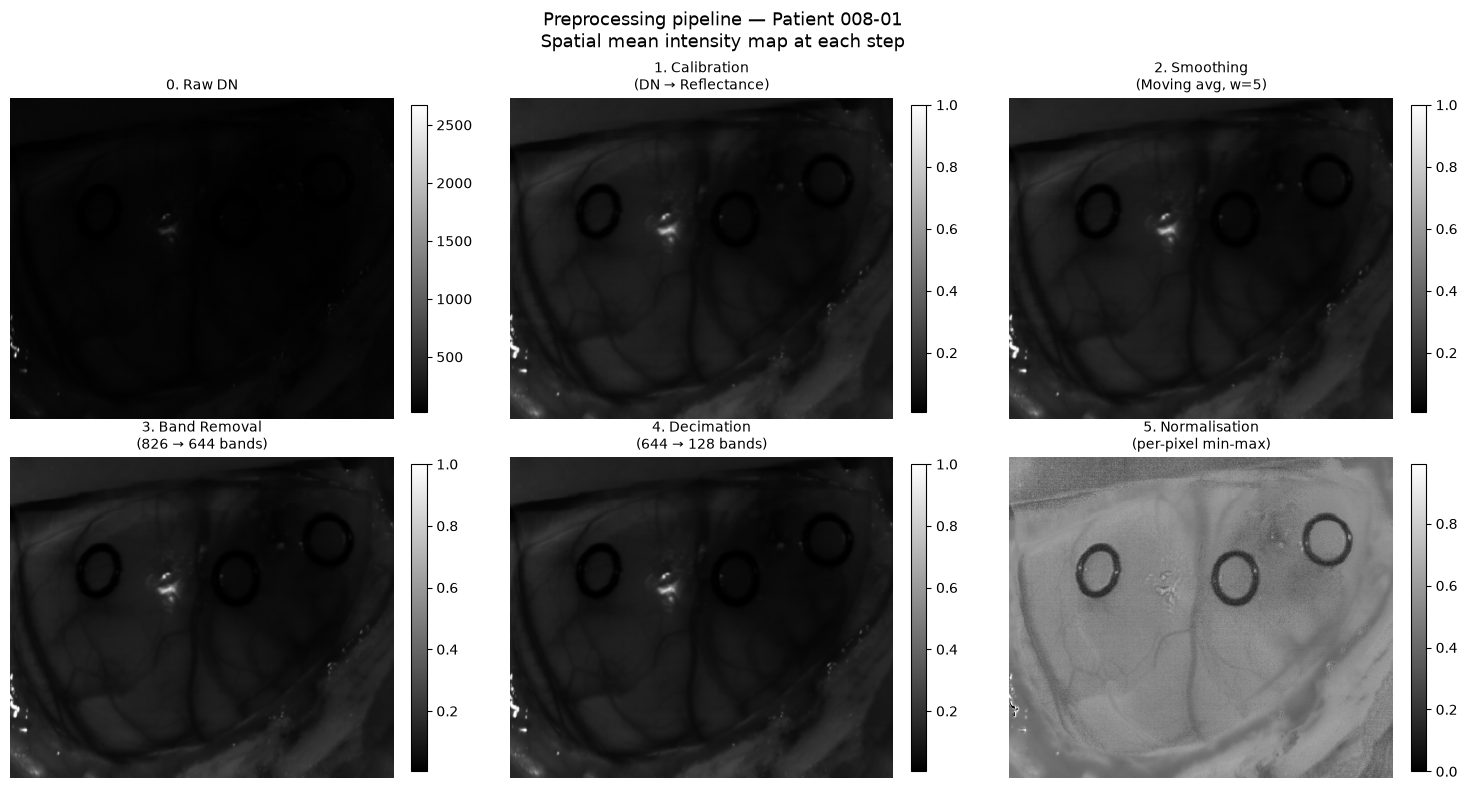

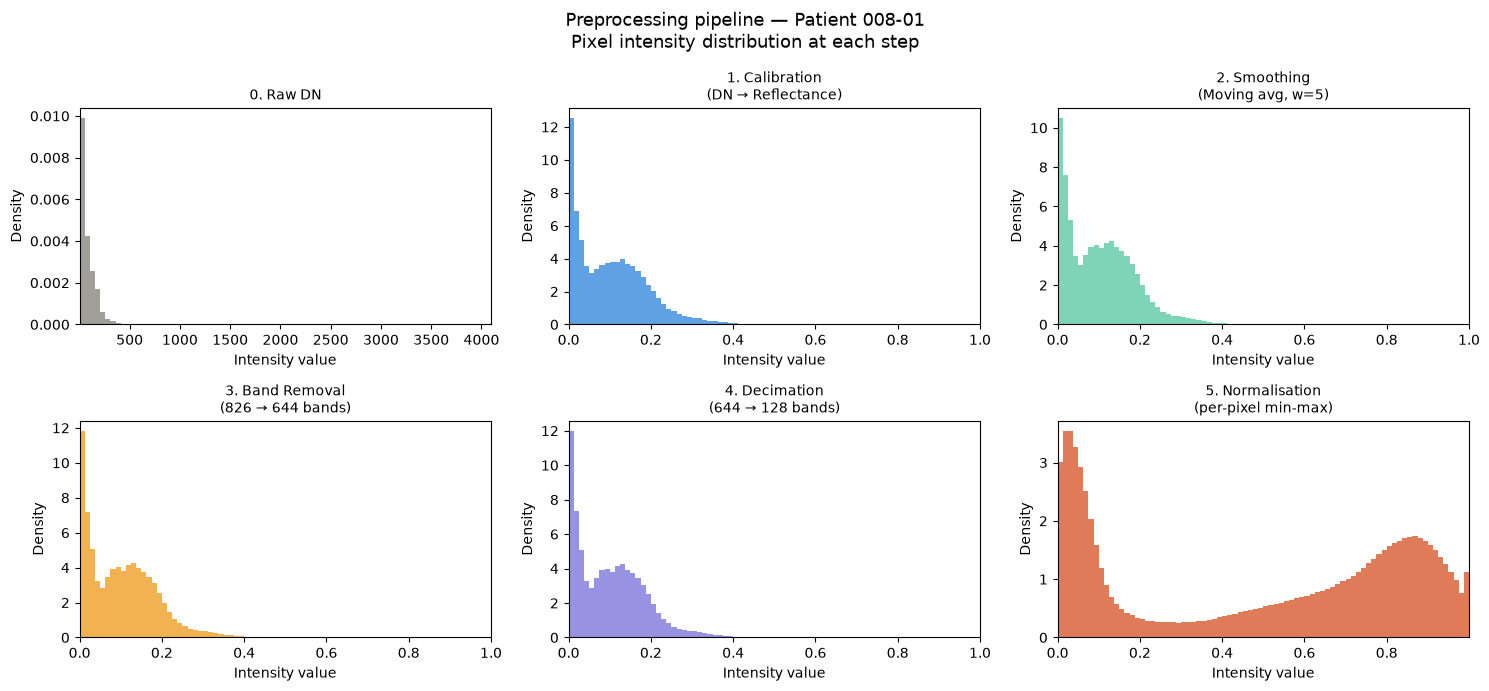


─────────────────────────────────────────────────────────────────
  Step                                          Shape      Min      Max     Mean
─────────────────────────────────────────────────────────────────
  0. Raw DN                           (460, 549, 826)    2.000  4095.000   82.011
  1. Calibration (DN → Reflectance)   (460, 549, 826)    0.000    1.000    0.105
  2. Smoothing (Moving avg, w=5)      (460, 549, 826)    0.000    1.000    0.105
  3. Band Removal (826 → 644 bands)   (460, 549, 644)    0.000    1.000    0.104
  4. Decimation (644 → 128 bands)     (460, 549, 128)    0.000    1.000    0.104
  5. Normalisation (per-pixel min-max) (460, 549, 128)    0.000    1.000    0.499
─────────────────────────────────────────────────────────────────


In [30]:
plot_preprocessing_pipeline(patient_path)